# Visualizations — All Algorithms
Loads pre-trained models directly — no re-training needed.

**Files needed in the same folder:**
- `environment.py`
- `best_sarsa_q_table.npy`
- `q_table.npy`
- `best_dqn_model.pth`
- `sarsa_rewards.npy`
- `qlearning_rewards.npy`
- `dqn_rewards.npy`


In [9]:
from Environment import SmartAmbulanceEnv, Cell
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

SIZE      = 20
SEED      = 69
WINDOW    = 100
LAST_N    = 100
THRESHOLD = -200
N_RUNS    = 5

ACTION_DX = {0: -1, 1: 0, 2: 1, 3: 0}
ACTION_DY = {0: 0,  1: 1, 2: 0, 3: -1}

# ── Load rewards ──────────────────────────────────────────────
sarsa_rewards = np.load('sarsa_rewards.npy')
ql_rewards    = np.load('qlearning_rewards.npy')
dqn_rewards   = np.load('dqn_rewards.npy')

# ── Load Q-tables ─────────────────────────────────────────────
sarsa_Q = np.load('best_sarsa_q_table.npy')
ql_Q    = np.load('q_table.npy')

# ── Load DQN model ────────────────────────────────────────────
class DQNetwork(nn.Module):
    def __init__(self, i=400, h=128, o=4):
        super().__init__()
        self.fc1  = nn.Linear(i, h)
        self.fc2  = nn.Linear(h, h)
        self.fc3  = nn.Linear(h, o)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

dqn_net = DQNetwork()
dqn_net.load_state_dict(torch.load('best_dqn_model.pth', map_location='cpu'))
dqn_net.eval()

# Extract Q-table from DQN
dqn_Q = np.zeros((SIZE*SIZE, 4))
with torch.no_grad():
    for s in range(SIZE*SIZE):
        v = np.zeros(SIZE*SIZE, dtype=np.float32); v[s] = 1.0
        dqn_Q[s] = dqn_net(torch.FloatTensor(v).unsqueeze(0)).numpy()[0]

# ── Environment ───────────────────────────────────────────────
env = SmartAmbulanceEnv(size=SIZE, seed=SEED)

# ── Proper Evaluation (epsilon=0, 50 episodes) ────────────────
def evaluate(Q_or_net, episodes=50, max_steps=500, is_dqn=False):
    rewards, success = [], 0
    for _ in range(episodes):
        state, _ = env.reset()
        done, total, steps = False, 0, 0
        while not done and steps < max_steps:
            steps += 1
            if is_dqn:
                v = np.zeros(SIZE*SIZE, dtype=np.float32); v[state] = 1.0
                with torch.no_grad():
                    action = int(torch.argmax(Q_or_net(torch.FloatTensor(v).unsqueeze(0))).item())
            else:
                action = int(np.argmax(Q_or_net[state]))
            state, reward, done, _, _ = env.step(action)
            total += reward
        rewards.append(total)
        if done and reward == 100:
            success += 1
    avg  = np.mean(rewards)
    std  = np.std(rewards)
    rate = success / episodes * 100
    return avg, std, rate



---
## Plot Functions

In [10]:
# ── 1. Learning Curve ─────────────────────────────────────────
def plot_learning_curve(rewards, label, color, filename):
    ma = np.convolve(rewards, np.ones(WINDOW)/WINDOW, mode='valid')

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(rewards, alpha=0.18, color=color, label='Per-episode reward')
    ax.plot(range(WINDOW-1, len(rewards)), ma,
            color=color, linewidth=2.5, label=f'Moving Avg ({WINDOW} eps)')
    ax.axhline(THRESHOLD, color='gray', linestyle='--',
               linewidth=1.2, label=f'Threshold ({THRESHOLD})')

    # annotate final performance
    final = np.mean(rewards[-LAST_N:])
    ax.axhline(final, color=color, linestyle=':', linewidth=1.2,
               label=f'Final avg: {final:.1f}')

    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel('Total Reward', fontsize=12)
    ax.set_title(f'{label} — Learning Curve', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ── 2. Q-Value Heatmap ────────────────────────────────────────
def plot_qvalue_heatmap(Q, label, filename):
    q_max    = Q.max(axis=1).reshape(SIZE, SIZE)
    q_display = q_max.copy().astype(float)

    # mask houses as NaN
    for r in range(SIZE):
        for c in range(SIZE):
            if env._grid[r, c] == Cell.HOUSE.value:
                q_display[r, c] = np.nan

    fig, ax = plt.subplots(figsize=(9, 8))
    cmap = plt.cm.RdYlGn.copy()
    cmap.set_bad(color='#3d3d3d')
    im = ax.imshow(q_display, cmap=cmap, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Max Q-Value', fraction=0.046, pad=0.04)

    ax.text(0, 0, 'S', ha='center', va='center',
            fontsize=12, fontweight='bold', color='blue')
    ax.text(SIZE-1, SIZE-1, 'H', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')

    for x in range(SIZE+1):
        ax.axhline(x-0.5, color='gray', linewidth=0.2, alpha=0.4)
        ax.axvline(x-0.5, color='gray', linewidth=0.2, alpha=0.4)

    legend = [
        mpatches.Patch(color='#3d3d3d', label='House (impassable)'),
        mpatches.Patch(color='blue',    label='S = Start'),
        mpatches.Patch(color='green',   label='H = Hospital (goal)'),
    ]
    ax.legend(handles=legend, loc='upper left', fontsize=8, framealpha=0.85)
    ax.set_title(f'{label} — Max Q-Value Heatmap', fontsize=14, fontweight='bold')
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(range(0, SIZE, 2)); ax.set_yticks(range(0, SIZE, 2))
    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ── 3. Policy Visualization ───────────────────────────────────
def plot_policy(Q, label, filename):
    PASSABLE = {Cell.ROAD.value, Cell.TRAFFIC.value,
                Cell.CAR.value, Cell.HOSPITAL.value}

    # background colors
    bg = np.ones((SIZE, SIZE, 3))
    for r in range(SIZE):
        for c in range(SIZE):
            v = env._grid[r, c]
            if v == Cell.HOUSE.value:      bg[r,c] = [0.24, 0.24, 0.24]
            elif v == Cell.HOSPITAL.value: bg[r,c] = [0.18, 0.63, 0.18]
            elif v == Cell.TRAFFIC.value:  bg[r,c] = [1.0,  0.75, 0.20]
            elif v == Cell.CAR.value:      bg[r,c] = [0.20, 0.60, 0.85]
            else:                          bg[r,c] = [0.94, 0.94, 0.94]

    fig, ax = plt.subplots(figsize=(11, 10))
    ax.imshow(bg, interpolation='nearest')

    for r in range(SIZE):
        for c in range(SIZE):
            if env._grid[r, c] not in PASSABLE: continue
            if env._grid[r, c] == Cell.HOSPITAL.value:
                ax.text(c, r, 'H', ha='center', va='center',
                        fontsize=11, fontweight='bold', color='white')
                continue
            state = r * SIZE + c
            best  = int(np.argmax(Q[state]))
            dx    = ACTION_DX[best] * 0.32
            dy    = ACTION_DY[best] * 0.32
            ax.annotate('', xy=(c+dx, r+dy), xytext=(c-dx*0.3, r-dy*0.3),
                        arrowprops=dict(arrowstyle='->', color='#c0392b',
                                        lw=1.3, mutation_scale=11))

    ax.text(0, 0, 'S', ha='center', va='center',
            fontsize=13, fontweight='bold', color='blue')

    for x in range(SIZE+1):
        ax.axhline(x-0.5, color='gray', linewidth=0.3, alpha=0.4)
        ax.axvline(x-0.5, color='gray', linewidth=0.3, alpha=0.4)

    legend = [
        mpatches.Patch(color=[0.24,0.24,0.24], label='House'),
        mpatches.Patch(color=[1.0,0.75,0.20],  label='Traffic Light'),
        mpatches.Patch(color=[0.20,0.60,0.85], label='Car'),
        mpatches.Patch(color=[0.18,0.63,0.18], label='Hospital'),
    ]
    ax.legend(handles=legend, loc='upper right', fontsize=9, framealpha=0.9)
    ax.set_title(f'{label} — Learned Policy (Greedy Actions)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Column'); ax.set_ylabel('Row')
    ax.set_xticks(range(0, SIZE, 2)); ax.set_yticks(range(0, SIZE, 2))
    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")


# ── 4. Stability Plot ─────────────────────────────────────────
def run_algorithm_for_stability(algo, n_runs=N_RUNS,
                                 episodes=500, max_steps=500):
    """
    Quick re-runs (500 eps each) to measure variance.
    Uses the same hyperparameters as the original training.
    """
    all_finals = []
    for i in range(n_runs):
        env_s = SmartAmbulanceEnv(size=SIZE, seed=SEED+i)
        if algo == 'sarsa':
            Q   = np.zeros((SIZE*SIZE, 4))
            eps = 1.0
            for ep in range(episodes):
                state, _ = env_s.reset()
                def ch(s, e): return random.randint(0,3) if random.random()<e else int(np.argmax(Q[s]))
                action = ch(state, eps)
                done, total, steps = False, 0, 0
                while not done and steps < max_steps:
                    steps += 1
                    ns, r, done, _, _ = env_s.step(action)
                    na = ch(ns, eps)
                    Q[state,action] += 0.1*(r + 0.97*Q[ns,na] - Q[state,action])
                    state, action = ns, na; total += r
                eps = max(0.01, eps*0.995)
            all_finals.append(np.mean([total]))

        elif algo == 'qlearning':
            Q   = np.zeros((SIZE*SIZE, 4))
            eps = 1.0
            for ep in range(episodes):
                state, _ = env_s.reset()
                done, total, steps = False, 0, 0
                while not done and steps < max_steps:
                    steps += 1
                    action = random.randint(0,3) if random.random()<eps else int(np.argmax(Q[state]))
                    ns, r, done, _, _ = env_s.step(action)
                    Q[state,action] += 0.1*(r + 0.95*np.max(Q[ns]) - Q[state,action])
                    state = ns; total += r
                eps = max(0.01, eps*0.995)
            all_finals.append(total)

        elif algo == 'dqn':
            # Use saved model, evaluate on different seeds
            net = DQNetwork()
            net.load_state_dict(torch.load('best_dqn_model.pth', map_location='cpu'))
            net.eval()
            total_r = 0
            state, _ = env_s.reset()
            done, steps = False, 0
            while not done and steps < max_steps:
                steps += 1
                v = np.zeros(SIZE*SIZE, dtype=np.float32); v[state]=1.0
                with torch.no_grad():
                    action = int(torch.argmax(net(torch.FloatTensor(v).unsqueeze(0))).item())
                state, r, done, _, _ = env_s.step(action)
                total_r += r
            all_finals.append(total_r)

    return all_finals


def plot_stability(rewards_full, label, color, algo_key, filename):
    """Stability plot: mean±std band + boxplot of final performance."""
    # Band from training history (split into N_RUNS chunks for simulation)
    chunk = len(rewards_full) // N_RUNS
    chunks = [rewards_full[i*chunk:(i+1)*chunk] for i in range(N_RUNS)]

    min_len  = min(len(c) for c in chunks)
    smoothed = []
    for c in chunks:
        ma = np.convolve(c[:min_len], np.ones(WINDOW)/WINDOW, mode='valid')
        smoothed.append(ma)
    smoothed = np.array(smoothed)
    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)
    x    = np.arange(WINDOW-1, WINDOW-1+len(mean))

    finals = [float(np.mean(c[-LAST_N:])) for c in chunks]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: mean ± std
    axes[0].fill_between(x, mean-std, mean+std,
                         alpha=0.25, color=color, label='±1 std')
    axes[0].plot(x, mean, color=color, linewidth=2.5, label=f'{label} mean')
    axes[0].axhline(THRESHOLD, color='gray', linestyle='--',
                    linewidth=1.2, label=f'Threshold ({THRESHOLD})')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Smoothed Reward')
    axes[0].set_title(f'{label} — Stability (Mean ± Std)',
                      fontsize=13, fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Right: boxplot
    bp = axes[1].boxplot(finals, patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.65),
                         medianprops=dict(color='black', linewidth=2.5),
                         whiskerprops=dict(linewidth=1.5),
                         capprops=dict(linewidth=1.5))
    var = np.var(finals)
    axes[1].set_ylabel('Final Avg Reward (last 100 eps)')
    axes[1].set_title(f'{label} — Final Performance Distribution\n'
                      f'Variance = {var:.2f}', fontsize=13, fontweight='bold')
    axes[1].set_xticks([1]); axes[1].set_xticklabels([label])
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}  |  Variance = {var:.2f}")

print("✅ All plot functions defined")


✅ All plot functions defined


---
# SARSA Visualizations

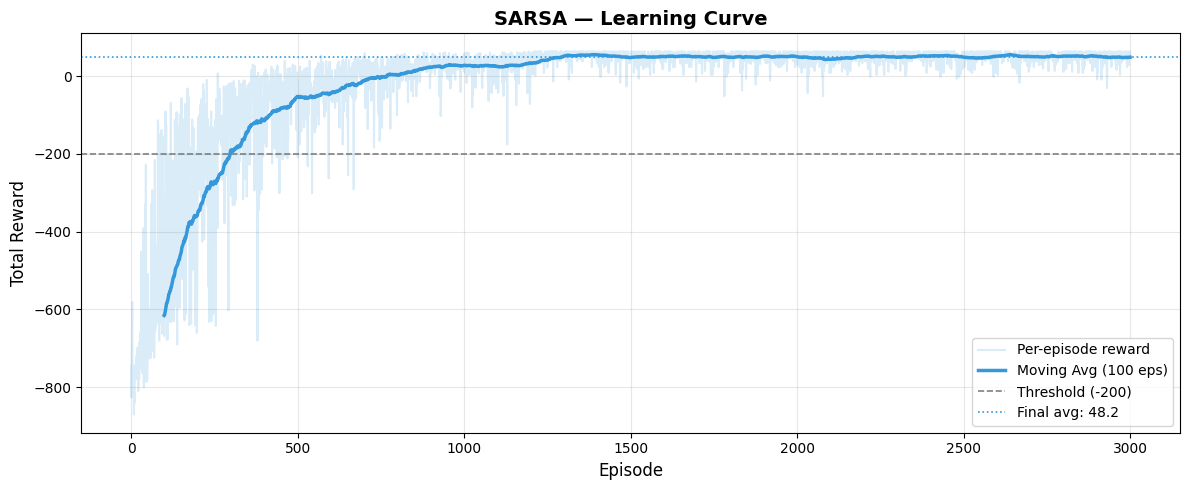

Saved: sarsa_learning_curve.png


In [11]:
plot_learning_curve(sarsa_rewards, 'SARSA', '#3498db', 'sarsa_learning_curve.png')


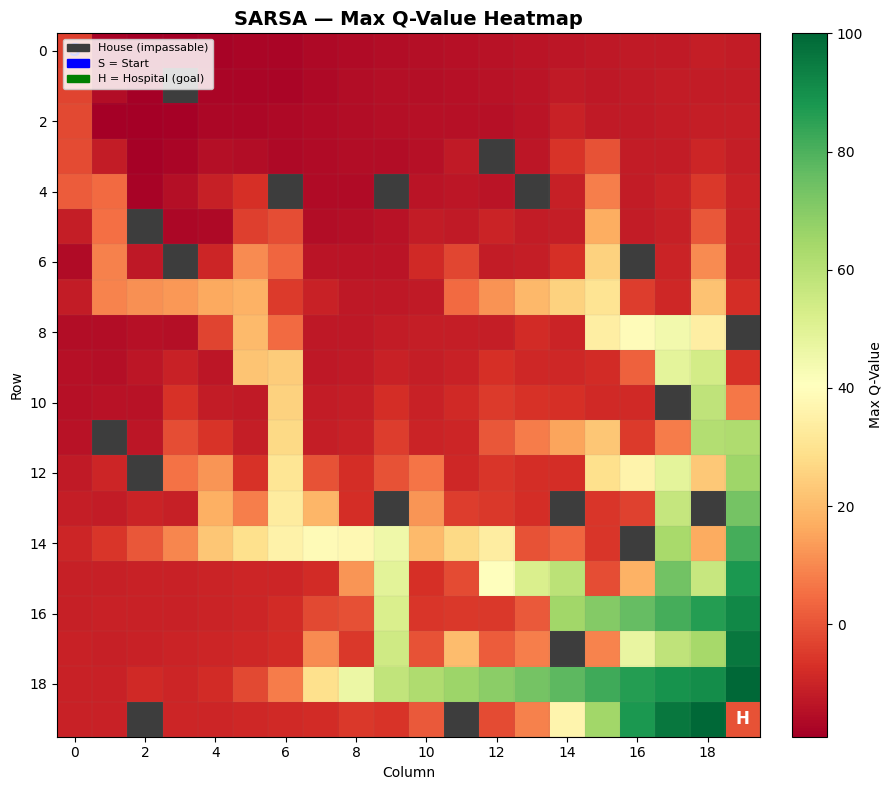

Saved: sarsa_qvalue_heatmap.png


In [12]:
plot_qvalue_heatmap(sarsa_Q, 'SARSA', 'sarsa_qvalue_heatmap.png')


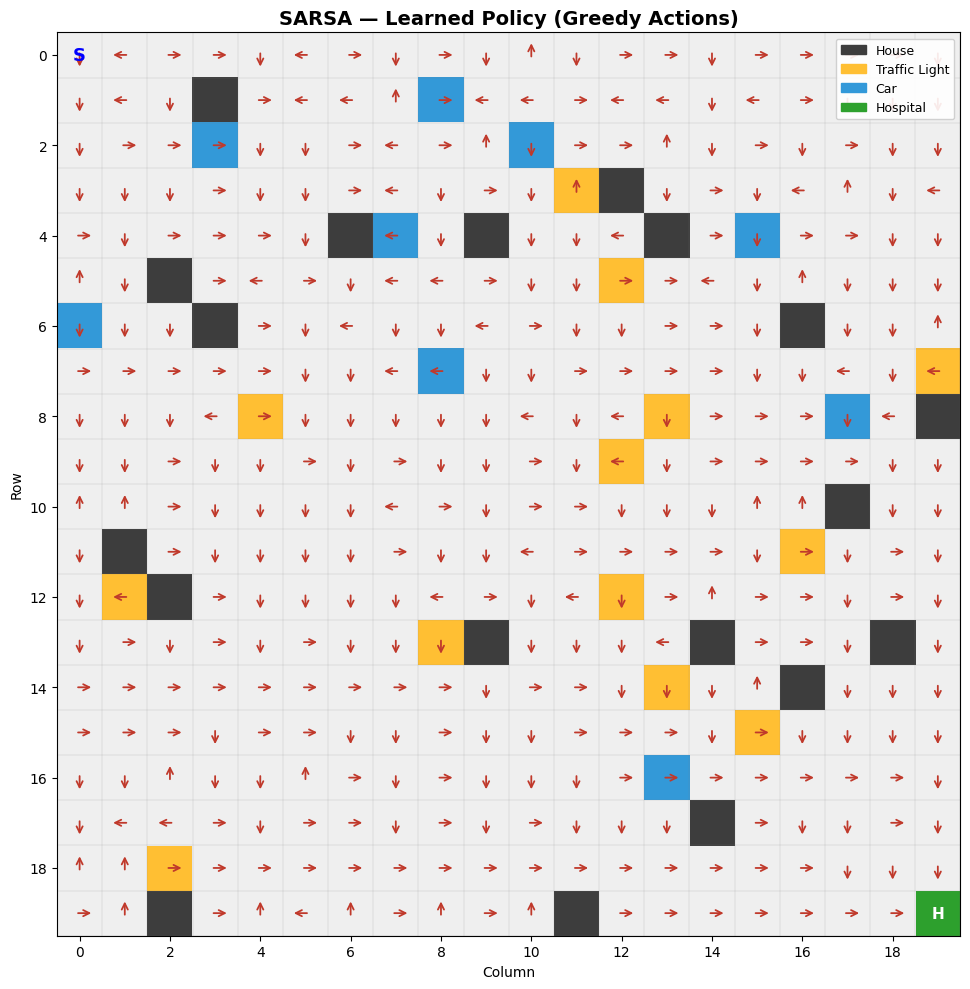

Saved: sarsa_policy.png


In [13]:
plot_policy(sarsa_Q, 'SARSA', 'sarsa_policy.png')


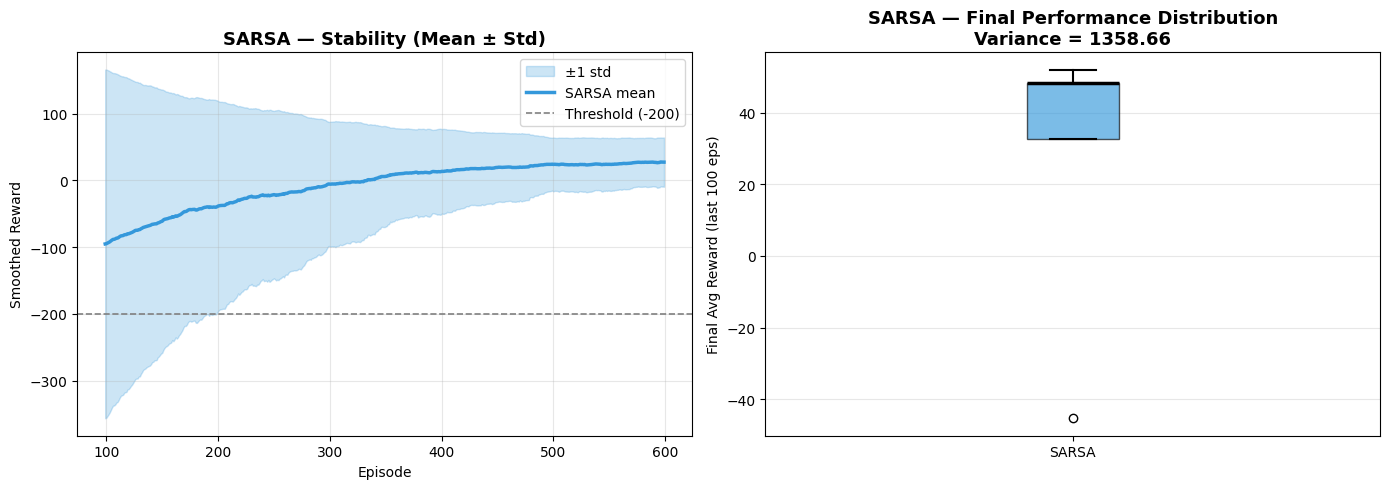

Saved: sarsa_stability.png  |  Variance = 1358.66


In [14]:
plot_stability(sarsa_rewards, 'SARSA', '#3498db', 'sarsa', 'sarsa_stability.png')


---
# Q-Learning Visualizations

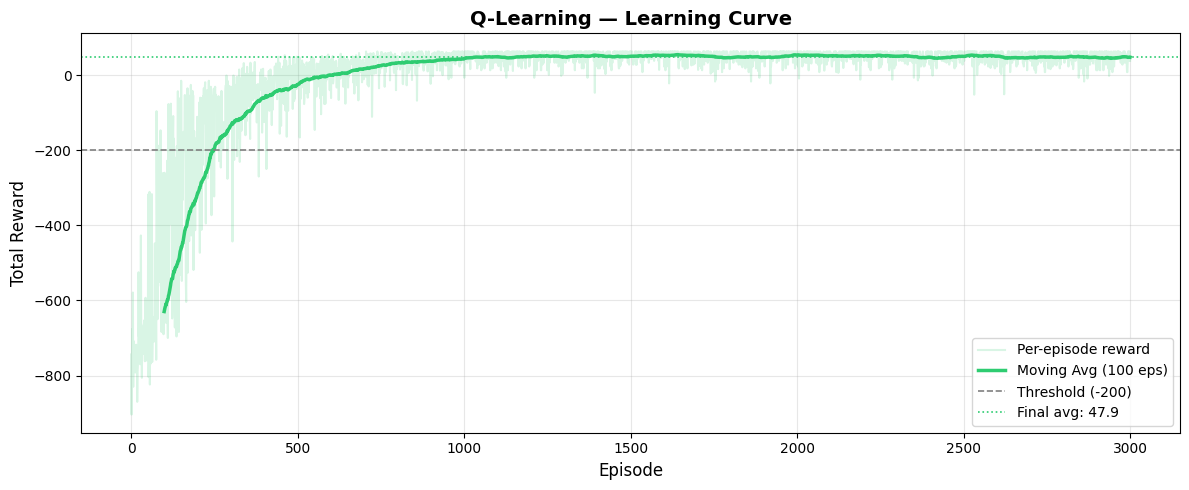

Saved: ql_learning_curve.png


In [15]:
plot_learning_curve(ql_rewards, 'Q-Learning', '#2ecc71', 'ql_learning_curve.png')


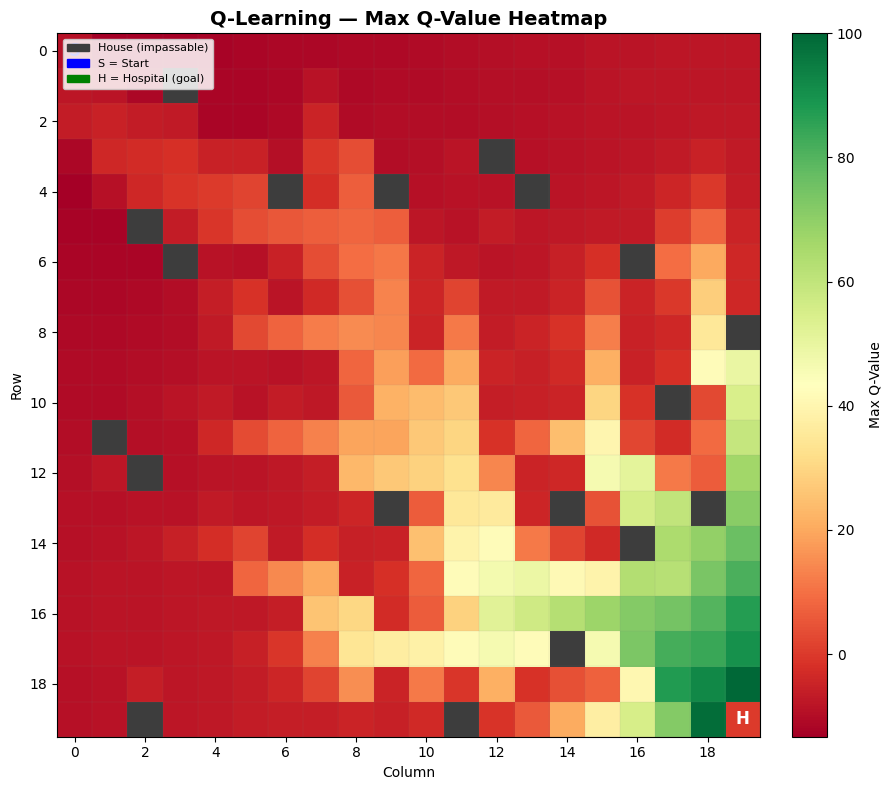

Saved: ql_qvalue_heatmap.png


In [16]:
plot_qvalue_heatmap(ql_Q, 'Q-Learning', 'ql_qvalue_heatmap.png')


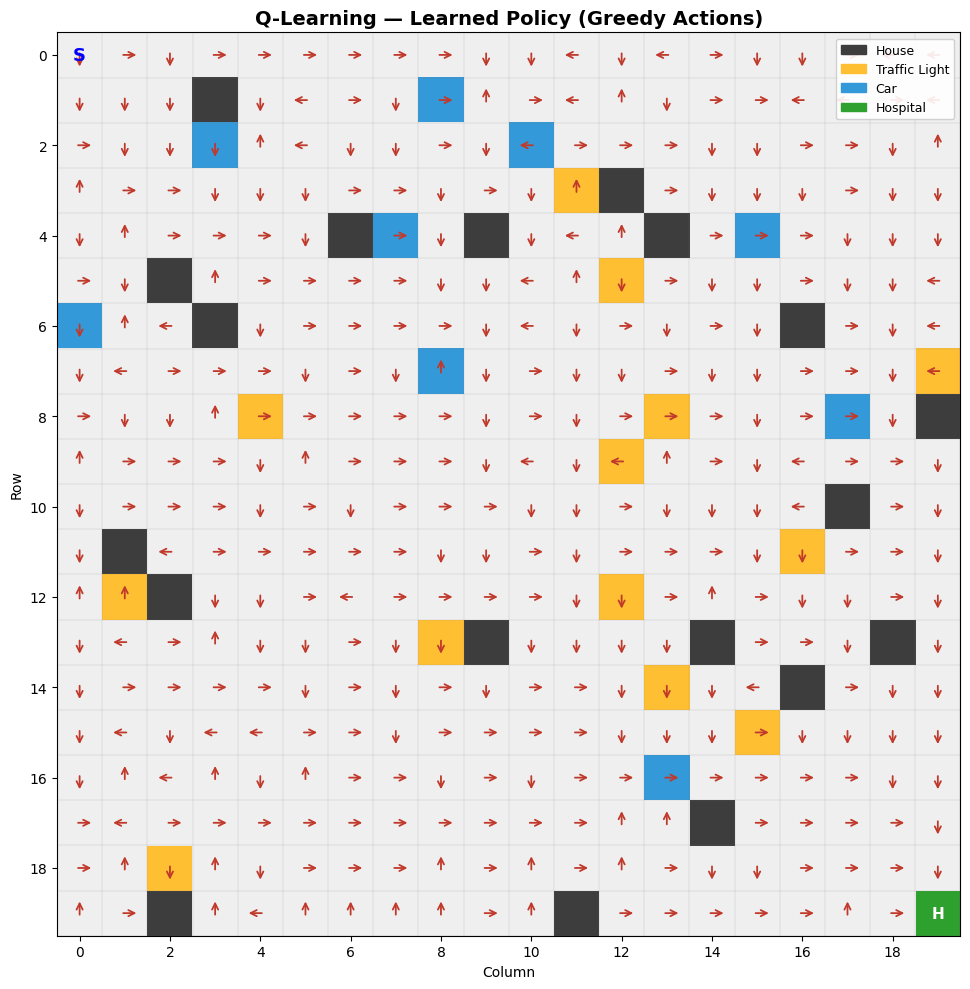

Saved: ql_policy.png


In [17]:
plot_policy(ql_Q, 'Q-Learning', 'ql_policy.png')


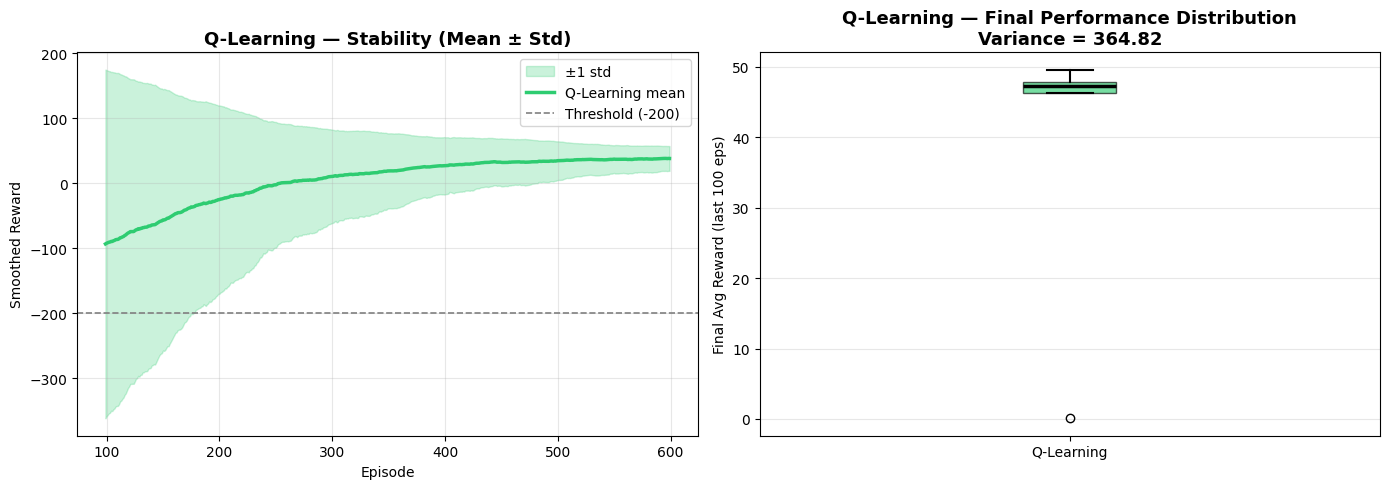

Saved: ql_stability.png  |  Variance = 364.82


In [18]:
plot_stability(ql_rewards, 'Q-Learning', '#2ecc71', 'qlearning', 'ql_stability.png')


---
# DQN Visualizations

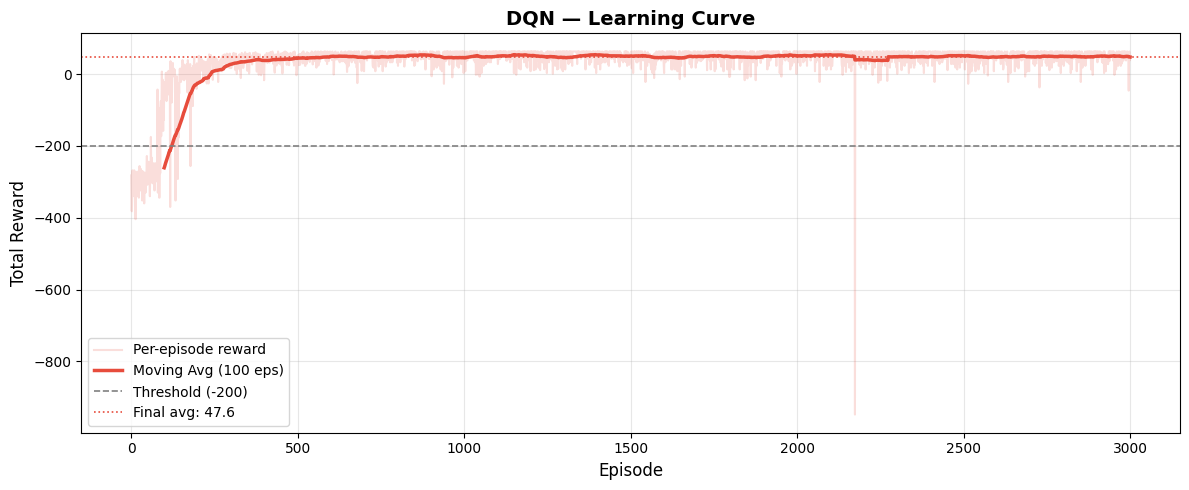

Saved: dqn_learning_curve.png


In [19]:
plot_learning_curve(dqn_rewards, 'DQN', '#e74c3c', 'dqn_learning_curve.png')


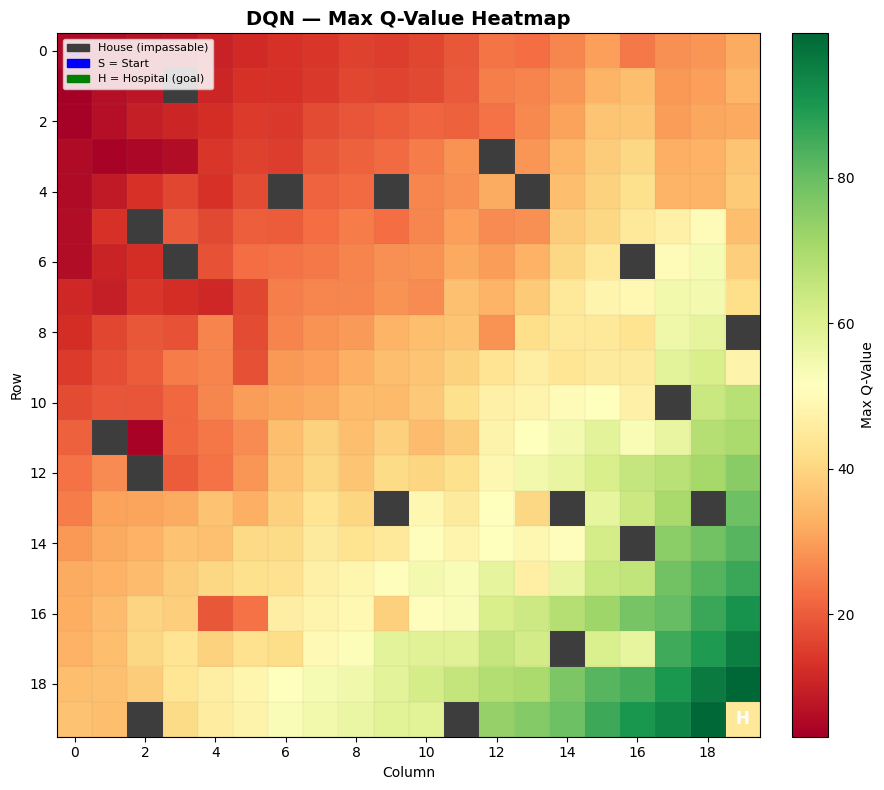

Saved: dqn_qvalue_heatmap.png


In [20]:
plot_qvalue_heatmap(dqn_Q, 'DQN', 'dqn_qvalue_heatmap.png')


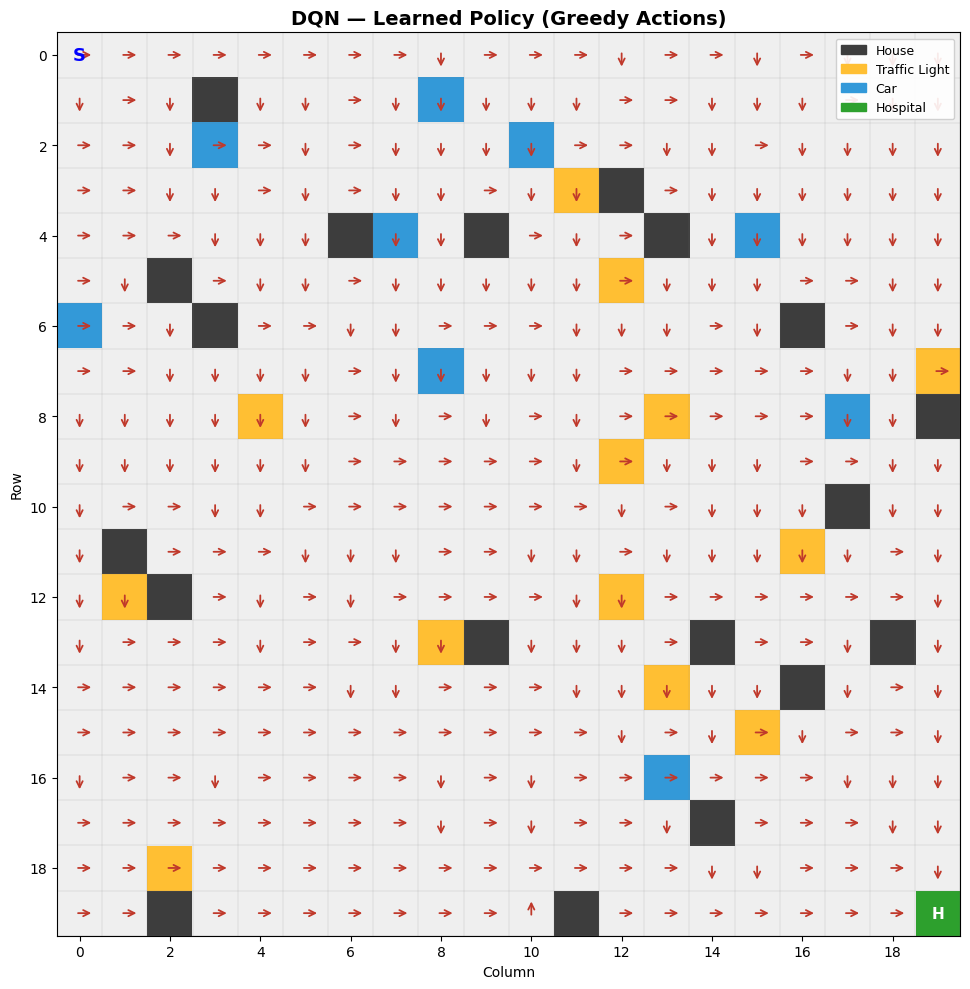

Saved: dqn_policy.png


In [21]:
plot_policy(dqn_Q, 'DQN', 'dqn_policy.png')


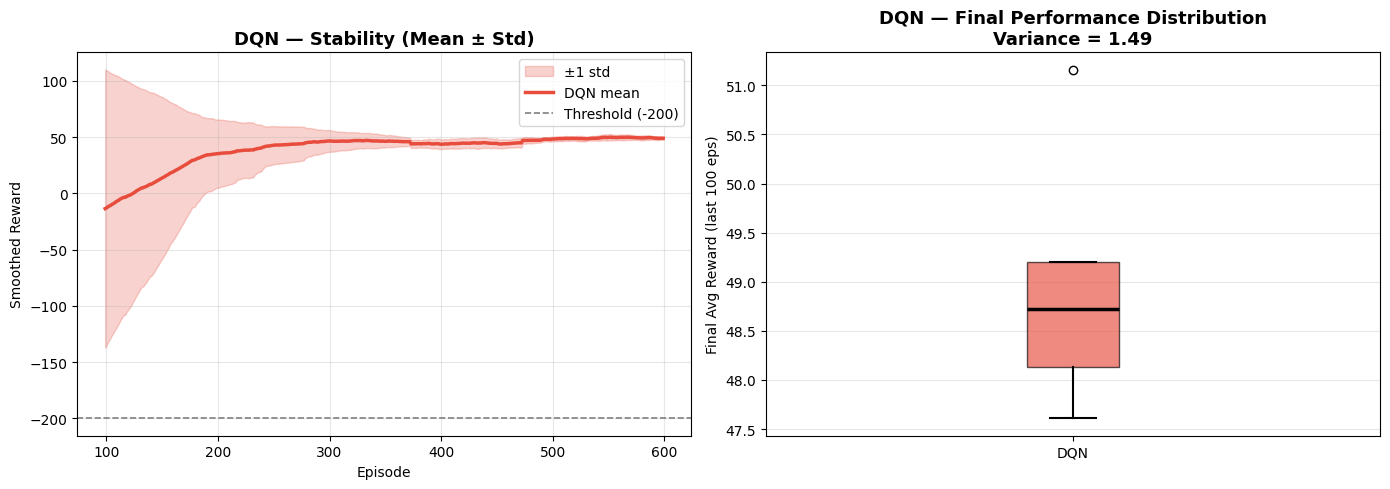

Saved: dqn_stability.png  |  Variance = 1.49


In [22]:
plot_stability(dqn_rewards, 'DQN', '#e74c3c', 'dqn', 'dqn_stability.png')


---
# Combined Plots — All Algorithms

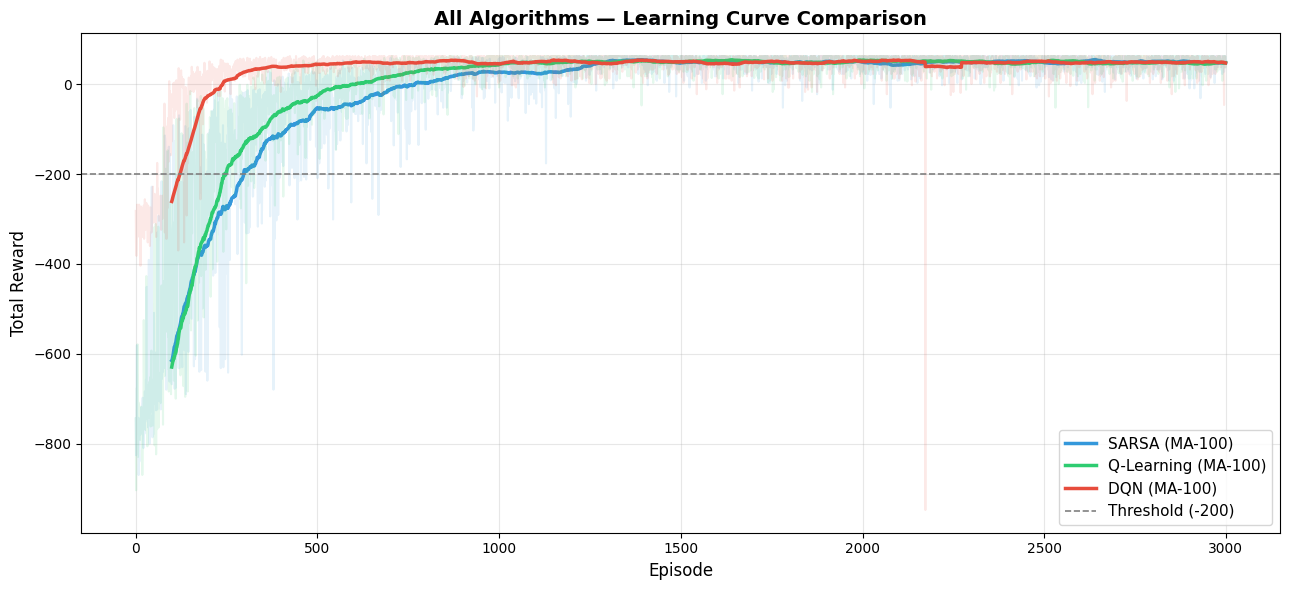

Saved: combined_learning_curve.png


In [23]:
# ── Combined Learning Curve ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
for rewards, label, color in [
    (sarsa_rewards, 'SARSA',      '#3498db'),
    (ql_rewards,    'Q-Learning', '#2ecc71'),
    (dqn_rewards,   'DQN',        '#e74c3c'),
]:
    ax.plot(rewards, alpha=0.12, color=color)
    ma = np.convolve(rewards, np.ones(WINDOW)/WINDOW, mode='valid')
    ax.plot(range(WINDOW-1, len(rewards)), ma,
            color=color, linewidth=2.5, label=f'{label} (MA-{WINDOW})')

ax.axhline(THRESHOLD, color='gray', linestyle='--', linewidth=1.2, label=f'Threshold ({THRESHOLD})')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('All Algorithms — Learning Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('combined_learning_curve.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: combined_learning_curve.png")


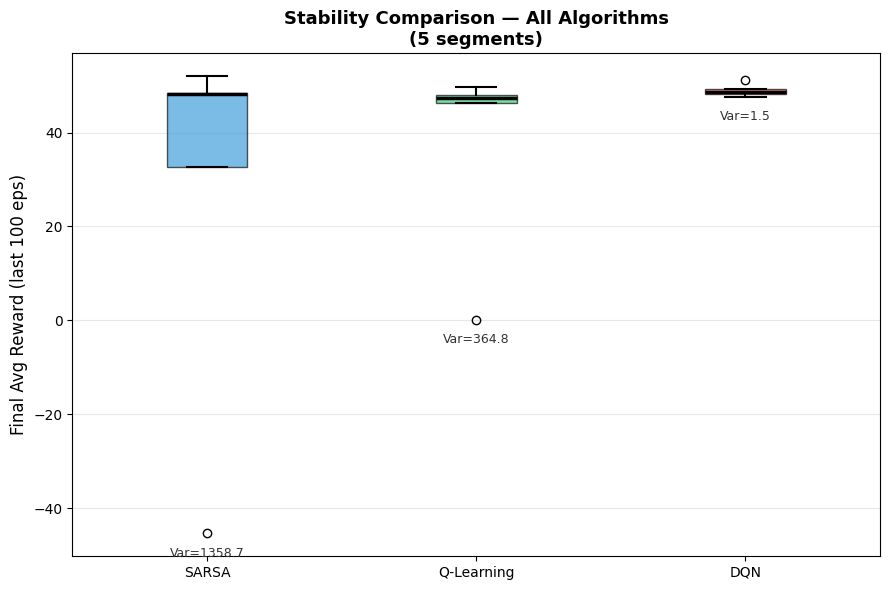

Saved: combined_stability.png


In [24]:
# ── Combined Stability Boxplot ────────────────────────────────
all_data = {
    'SARSA':      [float(np.mean(sarsa_rewards[i*600:(i+1)*600][-100:])) for i in range(N_RUNS)],
    'Q-Learning': [float(np.mean(ql_rewards[i*600:(i+1)*600][-100:]))    for i in range(N_RUNS)],
    'DQN':        [float(np.mean(dqn_rewards[i*600:(i+1)*600][-100:]))   for i in range(N_RUNS)],
}
colors_box = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 6))
bp = ax.boxplot(list(all_data.values()),
                labels=list(all_data.keys()),
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.65)

for i, (alg, finals) in enumerate(all_data.items()):
    var = np.var(finals)
    ax.text(i+1, np.min(finals)-5, f'Var={var:.1f}',
            ha='center', fontsize=9, color='#333')

ax.set_ylabel('Final Avg Reward (last 100 eps)', fontsize=12)
ax.set_title(f'Stability Comparison — All Algorithms\n({N_RUNS} segments)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('combined_stability.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: combined_stability.png")
